# PhysioTrust: Context-Aware Reliability Modeling

## Project Overview
PhysioTrust builds a software-based framework that evaluates the reliability of physiological data and enables safe, personalized health interpretation.

**Problem:** Wearable data is noisy. Trusting it blindly leads to false alarms.  
**Solution:** A Reliability Score (0-1) that acts as a gatekeeper for health interpretation.

# SECTION 1 — Dataset Management

**Instructions:**
1. Place your MIT-BIH Arrhythmia Database files in `data/raw/mitbih/`.
2. If you have a `.zip` file, place it in `data/` and run the cell below to extract it automatically.
3. Ensure that `100.dat`, `100.hea`, etc., are findable.

In [1]:
import os
import zipfile
import shutil

def setup_workspace():
    base_data_dir = "data"
    raw_dir = os.path.join(base_data_dir, "raw", "mitbih")
    
    if not os.path.exists(raw_dir):
        os.makedirs(raw_dir, exist_ok=True)
        print(f"[Setup] Created directory: {raw_dir}")
    
    # Check for zip files to extract
    for item in os.listdir(base_data_dir):
        if item.endswith(".zip"):
            zip_path = os.path.join(base_data_dir, item)
            print(f"[Setup] Found zip archive: {item}. Extracting...")
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(raw_dir)
            print("[Setup] Extraction complete.")
            
    # Check dataset existence
    if not os.path.exists(os.path.join(raw_dir, "100.hea")):
        print("[Warning] '100.hea' not found in raw directory.")
        print(f"Please ensure MIT-BIH data is placed in: {raw_dir}")
        # Attempt to handle if user put it in a subfolder inside raw
        for root, dirs, files in os.walk(base_data_dir):
            if "100.hea" in files:
                print(f"[Info] Found data in {root}. You may need to adjust paths or move files.")
    else:
        print("[Success] Dataset found successfully.")

setup_workspace()

[Success] Dataset found successfully.


# SECTION 2 — Imports & Core Logic Definitions
Consolidated logic from previous source modules for simplified execution.

In [2]:
import numpy as np
import scipy.signal
import scipy.stats
import wfdb
import matplotlib.pyplot as plt

print("[System] Libraries Imported.")

# ==========================================
# 1. PREPROCESSING
# ==========================================

def bandpass_filter(data, lowcut, highcut, fs, order=5):
    """Apply a Butterworth bandpass filter."""
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = scipy.signal.butter(order, [low, high], btype='band')
    y = scipy.signal.filtfilt(b, a, data)
    return y

def normalize_signal(data):
    """Z-score normalization."""
    mean = np.mean(data)
    std = np.std(data)
    if std == 0:
        return data - mean
    return (data - mean) / std

def window_signal(data, window_size_sec, fs, overlap_sec=0):
    """Segment the signal into fixed-size windows."""
    window_samples = int(window_size_sec * fs)
    overlap_samples = int(overlap_sec * fs)
    step = window_samples - overlap_samples
    
    if step <= 0:
        raise ValueError("Overlap must be smaller than window size")
        
    n_windows = (len(data) - window_samples) // step + 1
    
    windows = []
    for i in range(n_windows):
        start = i * step
        end = start + window_samples
        windows.append(data[start:end])
        
    return np.array(windows)

def preprocess_pipeline(data, fs):
    """Filter -> Normalize."""
    filtered = bandpass_filter(data, lowcut=0.5, highcut=50.0, fs=fs)
    normalized = normalize_signal(filtered)
    return normalized

# ==========================================
# 2. DATA LOADING
# ==========================================

def load_signal(subject_id='100', subset='mitbih'):
    """Loads one subject's signal using wfdb."""
    base_path = os.path.join('data', 'raw', subset, subject_id)
    try:
        record = wfdb.rdrecord(base_path)
        print(f"[Data Loader] Loaded {record.record_name}, Fs={record.fs}Hz")
        return {
            'signal': record.p_signal[:, 0], # Return lead 0
            'fs': record.fs,
            'name': record.record_name
        }
    except Exception as e:
        print(f"[Error] Failed to load {base_path}: {e}")
        return None

# ==========================================
# 3. QUALITY METRICS & RELIABILITY
# ==========================================

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def extract_quality_features(signal_window):
    """Extracts variance, entropy, snr, zcr, kurtosis."""
    # Variance
    var = np.var(signal_window)
    
    # Entropy
    hist, _ = np.histogram(signal_window, bins=20, density=True)
    hist = hist[hist > 0]
    entropy = -np.sum(hist * np.log2(hist))
    
    # SNR Proxy (Power)
    sig_power = np.mean(signal_window ** 2)
    snr = 10 * np.log10(sig_power) if sig_power > 0 else 0
    
    # Zero Crossings
    zcr = len(np.where(np.diff(np.sign(signal_window)))[0])
    
    # Kurtosis
    kurt = scipy.stats.kurtosis(signal_window)
    
    return {
        'variance': var,
        'entropy': entropy,
        'snr_proxy': snr,
        'zero_crossings': zcr,
        'kurtosis': kurt
    }

def calculate_reliability_score(signal_window):
    """Computes a 0-1 reliability score based on signal quality."""
    features = extract_quality_features(signal_window)
    
    # 1. Entropy Score (Lower is better for structured ECG)
    entropy_score = 1.0 / (1.0 + features['entropy'])
    
    # 2. Kurtosis Score (Higher is better for peaky ECG)
    kurtosis_score = sigmoid((features['kurtosis'] - 3) / 2)
    
    # 3. Variance Score (Penalty for flatline)
    variance_score = sigmoid((features['variance'] - 0.1) * 10)
    
    # Weighted Combination
    weights = {'entropy': 0.4, 'kurtosis': 0.4, 'variance': 0.2}
    reliability = (weights['entropy'] * entropy_score + 
                   weights['kurtosis'] * kurtosis_score + 
                   weights['variance'] * variance_score)
                   
    return np.clip(reliability, 0, 1)

# ==========================================
# 4. CONTEXT & PERSONALIZATION
# ==========================================

class ContextAwareness:
    def __init__(self):
        self.context_thresholds = {
            'rest': 0.6,
            'walking': 0.4,
            'running': 0.3,
            'sleep': 0.7
        }
    
    def evaluate_reliability(self, score, context='rest'):
        threshold = self.context_thresholds.get(context, 0.5)
        is_reliable = score >= threshold
        status = "Reliable" if is_reliable else "Unreliable"
        return is_reliable, f"{status} (Score {score:.2f} vs Threshold {threshold})"

class PersonalizedBaseline:
    def __init__(self):
        self.history = []
        
    def update(self, metric_val, is_reliable):
        if is_reliable:
            self.history.append(metric_val)
            
    def get_baseline_mean(self):
        if not self.history: return 0
        return np.mean(self.history)


[System] Libraries Imported.


# SECTION 3 — Main Execution Loop
1. Load Data
2. Preprocess
3. Window & Analyze
4. Visualize Results

[Data Loader] Loaded 100, Fs=360Hz
[Analysis] Processing 361 windows of 5.0s each...


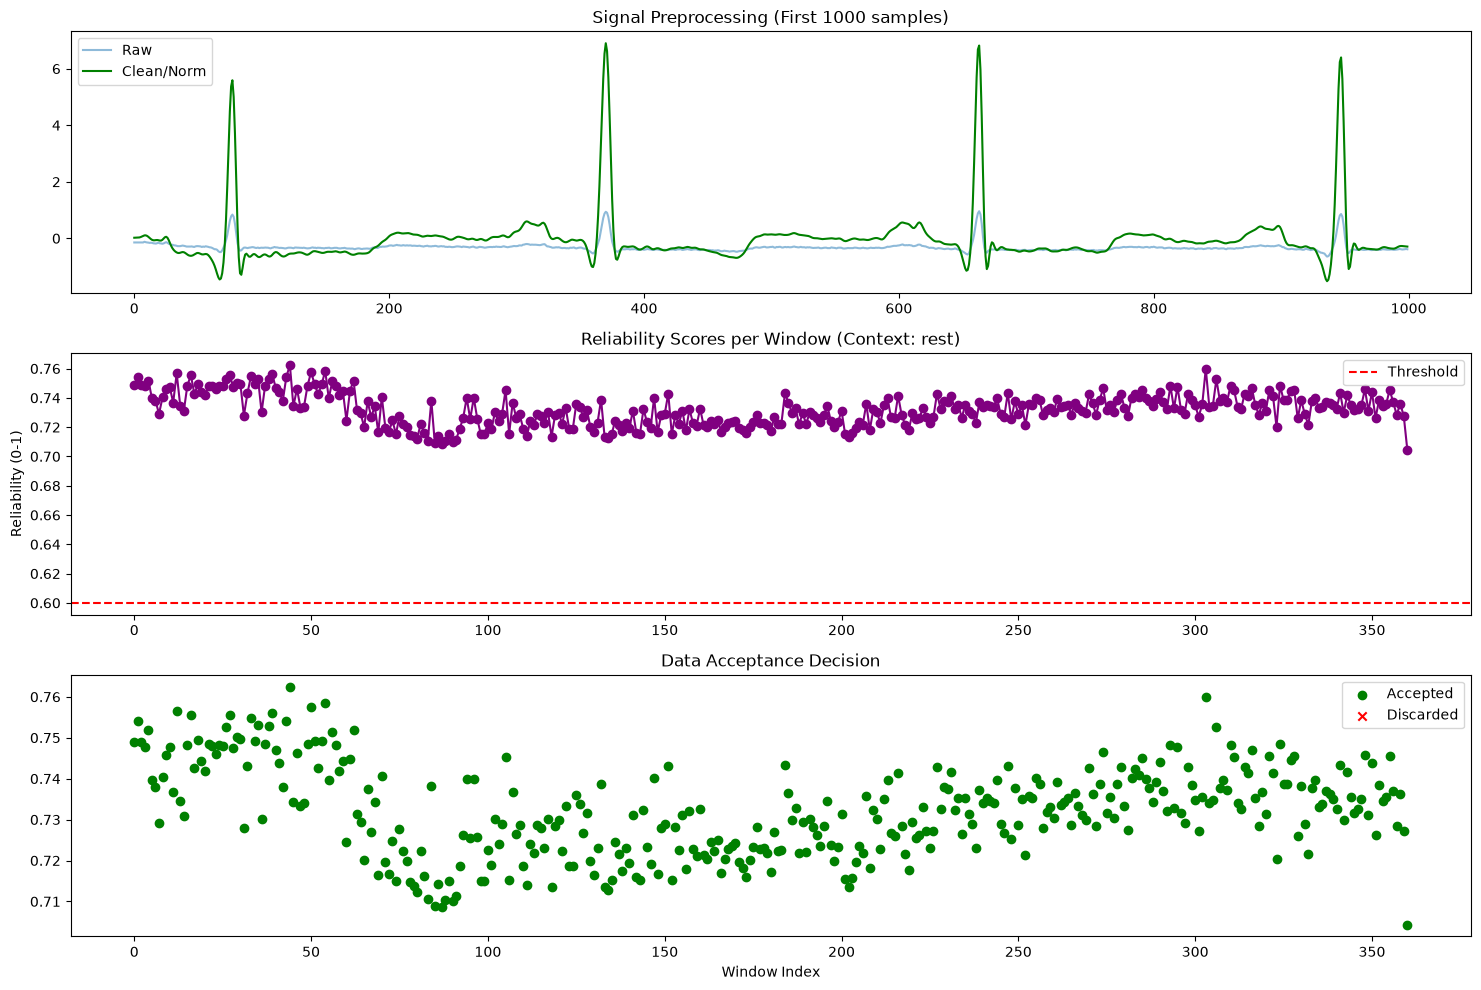

[Result] Processed 361 windows.
[Result] Acceptance Rate: 100.0%
[Result] Personalized Variance Baseline: 0.9984


In [3]:
# 1. Load Data
data_obj = load_signal(subject_id='100')

if data_obj is not None:
    raw_signal = data_obj['signal']
    fs = data_obj['fs']
    
    # 2. Preprocess
    clean_signal = preprocess_pipeline(raw_signal, fs)
    
    # 3. Window & Analyze
    window_sec = 5.0
    windows = window_signal(clean_signal, window_size_sec=window_sec, fs=fs)
    
    print(f"[Analysis] Processing {len(windows)} windows of {window_sec}s each...")
    
    reliability_scores = []
    decisions = []
    
    context_engine = ContextAwareness()
    baseline_engine = PersonalizedBaseline()
    
    # Simulate a context (e.g., 'rest')
    current_context = 'rest'
    
    for idx, win in enumerate(windows):
        # Compute intrinsic reliability
        score = calculate_reliability_score(win)
        reliability_scores.append(score)
        
        # Contextual Decision
        is_reliable, reason = context_engine.evaluate_reliability(score, context=current_context)
        decisions.append(is_reliable)
        
        # Update baseline if reliable (Tracking variance as a metric example)
        features = extract_quality_features(win)
        baseline_engine.update(features['variance'], is_reliable)
    
    # 4. Visualization
    plt.figure(figsize=(15, 10))
    
    # Plot Raw vs Clean (First 1000 samples)
    plt.subplot(3, 1, 1)
    plt.plot(raw_signal[:1000], label='Raw', alpha=0.5)
    plt.plot(clean_signal[:1000], label='Clean/Norm', color='green')
    plt.title("Signal Preprocessing (First 1000 samples)")
    plt.legend()
    
    # Plot Reliability Scores
    plt.subplot(3, 1, 2)
    plt.plot(reliability_scores, marker='o', linestyle='-', color='purple')
    plt.axhline(y=context_engine.context_thresholds[current_context], color='r', linestyle='--', label='Threshold')
    plt.title(f"Reliability Scores per Window (Context: {current_context})")
    plt.ylabel("Reliability (0-1)")
    plt.legend()
    
    # Plot Accepted vs Rejected Windows
    plt.subplot(3, 1, 3)
    accepted_indices = [i for i, x in enumerate(decisions) if x]
    rejected_indices = [i for i, x in enumerate(decisions) if not x]
    
    plt.scatter(accepted_indices, [reliability_scores[i] for i in accepted_indices], color='green', label='Accepted')
    plt.scatter(rejected_indices, [reliability_scores[i] for i in rejected_indices], color='red', label='Discarded', marker='x')
    plt.title("Data Acceptance Decision")
    plt.xlabel("Window Index")
    plt.legend()
    
    plt.tight_layout()
    # Save the analysis plot
    os.makedirs(os.path.join('results', 'plots'), exist_ok=True)
    plt.savefig(os.path.join('results', 'plots', 'reliability_analysis.png'), dpi=150)
    plt.show()
    
    # Save the summary table
    import pandas as pd
    os.makedirs(os.path.join('results', 'tables'), exist_ok=True)
    df_summary = pd.DataFrame({
        'Window_Index': range(len(windows)),
        'Reliability_Score': reliability_scores,
        'Accepted': decisions,
        'Context': [current_context] * len(windows)
    })
    df_summary.to_csv(os.path.join('results', 'tables', 'reliability_summary.csv'), index=False)
    
    # Save the baseline metrics
    with open(os.path.join('results', 'tables', 'baseline_metrics.txt'), 'w') as f:
        f.write(f"Processed Windows: {len(windows)}\n")
        f.write(f"Acceptance Rate: {sum(decisions)/len(decisions)*100:.1f}%\n")
        f.write(f"Personalized Variance Baseline: {baseline_engine.get_baseline_mean():.4f}\n")
    
    print(f"[Result] Processed {len(windows)} windows.")
    print(f"[Result] Acceptance Rate: {sum(decisions)/len(decisions)*100:.1f}%")
    print(f"[Result] Personalized Variance Baseline: {baseline_engine.get_baseline_mean():.4f}")
    
else:
    print("[Error] No data loaded. Please check the Dataset Management section.")